# 10/30 new table with the first version of (simple) features 

Key is [ENROLID, COST_YEAR] (or [ENROLID, CLAIM_YEAR] because CLAIM_YEAR is always COST_YEAR-1)

Number of enrollees per year:

+----------+--------+
|CLAIM_YEAR|   COUNT|
+----------+--------+
|      2014|19264519|
|      2015|21330307|
|      2016|18821468|
|      2017|17311177|
|      2018|16712290|
|      2019|15418046|
|      2020|14867116|
|      2021|14470056|
|      2022|14278277|
|      2023|14568251|
+----------+--------+

## Read in data + filter for 2017 and 2018 only

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:
spark = start_spark(num_nodes=10)

@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/charles/DATA/marketscan/data/normalized/features_v1"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/02 13:44:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/02 13:44:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/02 13:44:31 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
2025-11-02 13:44:33,886 INFO     >>> Reading enrollment file: /Users/charles/DATA/marketscan/data/normalized/features_v1
25/11/02 13:44:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-11-02 13:44:37,304 INFO     >>> ENROLLMENT has 167,041,507 rows            
2025-11-02 13:45:19,539 INFO     >>> ENROLLMENT has 55,86

In [3]:

spark_2018 = (
    df_enrollment
     .filter(F.col("COST_YEAR")== 2018)
     .filter(F.col("cluster_0")>0)
)
df_2018 = spark_2018.toPandas()
df_2018.head()

,ENROLID,EFAMID,COST_YEAR,CLAIM_YEAR,SEX,AGE,AGEGRP,AGE_BUCKET,EMPREL,COST_MEMDAYS,...,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9
0,27128501,271285,2018,2017,2,56,5,7,2,307,...,605.00,300.64,0.0,0.0,33817.21,0.00,19588.57,0.0,394.27,19952.23
1,32772005,327720,2018,2017,2,51,4,6,2,131,...,322.14,0.00,0.0,0.0,342.22,0.00,1924.13,0.0,318.76,523.90
2,128498602,1284986,2018,2017,2,60,5,7,2,365,...,651.17,0.00,0.0,0.0,0.00,1457.96,1118.51,0.0,541.67,0.00
3,129909401,1299094,2018,2017,2,59,5,7,1,365,...,160.02,0.00,0.0,0.0,0.00,0.00,911.90,0.0,945.72,0.00
4,131330202,1313302,2018,2017,2,61,5,7,2,334,...,1316.00,10.14,0.0,0.0,1850.05,0.00,3901.66,0.0,129.86,3114.60


## Get medications

In [4]:
print(df_2018.SEX.value_counts(normalize=True))
print(df_2018.AGEGRP.value_counts(normalize=True))
print(df_2018.REGION.value_counts(normalize=True))




SEX
2    0.529688
1    0.470312
Name: proportion, dtype: float64
AGEGRP
5    0.411005
4    0.244008
3    0.132009
2    0.128839
1    0.065397
6    0.018742
Name: proportion, dtype: float64
REGION
3    0.437339
2    0.224021
1    0.196683
4    0.139462
5    0.002496
Name: proportion, dtype: float64


In [ ]:
"""It has the following columns:

ENROLID: Enrollee ID
COST_YEAR: Target year (we want to predict the cost for this year)
CLAIM_YEAR: Observation year (use claims data from this year). Always equal to "COST_YEAR-1"
SEX: 1=male, 2=female
AGE: Age in year
AGEGRP: Marketscan's age group
COST_MEMDAYS: total membership/enrollment days during COST_YEAR
CLAIM_MEMDAYS: total membership/enrollment days during CLAIM_YEAR
RX: Rx flag (this person had Rx data during CLAIM_YEAR)
REGION: Marketscan's region (during CLAIM_YEAR)
INCOME_LEVEL: Median income level of MSA (during CLAIM_YEAR)
INDSTRY: Employer's industry
NETPAY_TOTAL_ADJ: Total plan cost during COST_YEAR (adjusted for inflation)
PREV_PAY_TOTAL_ADJ: Total cost during CLAIM_YEAR (adjusted for inflation)
PAY_TOTAL_ADJ: Total cost during COST_YEAR (adjusted for inflation)


EFAMID: Enrollee's Family ID
EMPREL: Relation to employee (1=Employee, 2=Spouse, 3=Child/dependent)
AGE_BUCKET: Our own age group
MSA: MSA of residence (during CLAIM_YEAR)
MSA_NEW: MSA of residence (during CLAIM_YEAR) - fixed by us
EGEOLOC: Geographic location (during CLAIM_YEAR)
groupid: Our own group id (practically useless nowdays...)
cluster_0: Total cost (during CLAIM_YEAR) for ICD codes in cluster #0
cluster_1: Total cost (during CLAIM_YEAR) for ICD codes in cluster #1
cluster_2: Total cost (during CLAIM_YEAR) for ICD codes in cluster #2
cluster_3: Total cost (during CLAIM_YEAR) for ICD codes in cluster #3
cluster_4: Total cost (during CLAIM_YEAR) for ICD codes in cluster #4
cluster_5: Total cost (during CLAIM_YEAR) for ICD codes in cluster #5
cluster_6: Total cost (during CLAIM_YEAR) for ICD codes in cluster #6
cluster_7: Total cost (during CLAIM_YEAR) for ICD codes in cluster #7
cluster_8: Total cost (during CLAIM_YEAR) for ICD codes in cluster #8
cluster_9: Total cost (during CLAIM_YEAR) for ICD codes in cluster #9"""


'It has the following columns:\n\nENROLID: Enrollee ID\nEFAMID: Enrollee\'s Family ID\nCOST_YEAR: Target year (we want to predict the cost for this year)\nCLAIM_YEAR: Observation year (use claims data from this year). Always equal to "COST_YEAR-1"\nSEX: 1=male, 2=female\nAGE: Age in year\nAGEGRP: Marketscan\'s age group\nAGE_BUCKET: Our own age group\nEMPREL: Relation to employee (1=Employee, 2=Spouse, 3=Child/dependent)\nCOST_MEMDAYS: total membership/enrollment days during COST_YEAR\nCLAIM_MEMDAYS: total membership/enrollment days during CLAIM_YEAR\nRX: Rx flag (this person had Rx data during CLAIM_YEAR)\nMSA: MSA of residence (during CLAIM_YEAR)\nMSA_NEW: MSA of residence (during CLAIM_YEAR) - fixed by us\nEGEOLOC: Geographic location (during CLAIM_YEAR)\nREGION: Marketscan\'s region (during CLAIM_YEAR)\nINCOME_LEVEL: Median income level of MSA (during CLAIM_YEAR)\nINDSTRY: Employer\'s industry\ngroupid: Our own group id (practically useless nowdays...)\nPAY_TOTAL_ADJ: Total cost du

## Cost Distribution Analysis by Cluster


In [9]:
# Summary statistics for each cluster
cluster_cols = [f'cluster_{i}' for i in range(10)]

print("="*80)
print("SUMMARY STATISTICS BY CLUSTER")
print("="*80)

stats_summary = []
for col in cluster_cols:
    cluster_data = df_2018[col]
    stats = {
        'Cluster': col,
        'Mean': cluster_data.mean(),
        'Median': cluster_data.median(),
        'Std': cluster_data.std(),
        'Min': cluster_data.min(),
        'Max': cluster_data.max(),
        'Q25': cluster_data.quantile(0.25),
        'Q75': cluster_data.quantile(0.75),
        'Non-Zero Count': (cluster_data > 0).sum(),
        'Non-Zero %': (cluster_data > 0).mean() * 100
    }
    stats_summary.append(stats)

stats_df = pd.DataFrame(stats_summary)
stats_df = stats_df.round(2)
print(stats_df.to_string(index=False))


SUMMARY STATISTICS BY CLUSTER
  Cluster     Mean  Median       Std        Min        Max     Q25      Q75  Non-Zero Count  Non-Zero %
cluster_0 21473.76 1055.00  76583.83       0.00 9672605.86  217.76 10596.74          264065      100.00
cluster_1  6852.08    0.00  59479.76 -497156.03 6076035.06    0.00   117.70           75426       28.56
cluster_2     0.01    0.00      2.93       0.00    1032.77    0.00     0.00              10        0.00
cluster_3     5.17    0.00    718.15       0.00  341109.41    0.00     0.00             571        0.22
cluster_4 21913.24  744.34  80148.17 -759752.76 9674551.90    0.00 12077.50          177196       67.10
cluster_5 11253.00    0.00  62523.83  -32335.02 4200792.07    0.00     0.00           45729       17.32
cluster_6 32360.55 8870.06  77198.80 -675498.59 5531094.43 2449.55 32096.35          262087       99.25
cluster_7   336.26    0.00  20710.03   -7698.22 5319670.81    0.00     0.00            2171        0.82
cluster_8  6317.07 1174.91  21574.

46.649082773144976


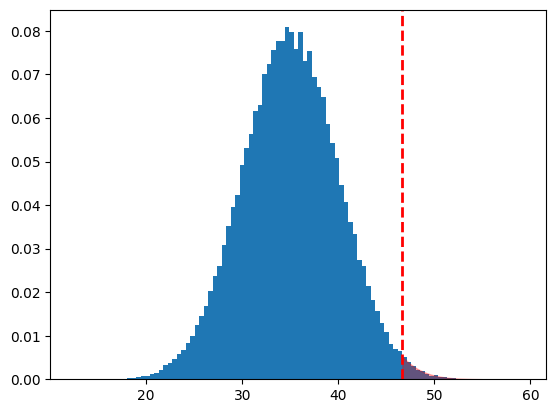

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- parameters ---
mu = 35        # mean braking distance (m)
sigma = 5      # std deviation (m)
n = 100_000    # number of simulated trips

# --- simulate braking distances ---
X = np.random.normal(mu,sigma,size=n)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

perc=0.99
threshold = np.percentile(X, 100 * perc)     # or mu + sigma * norm.ppf(p)
print(threshold)
plt.hist(X,bins=100,density=True)
plt.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"99th percentile = {threshold:.1f} m")
x_tail = x[x >= threshold]
plt.fill_between(x_tail, 0, norm.pdf(x_tail, mu, sigma), color='red', alpha=0.3, label='1% right tail')


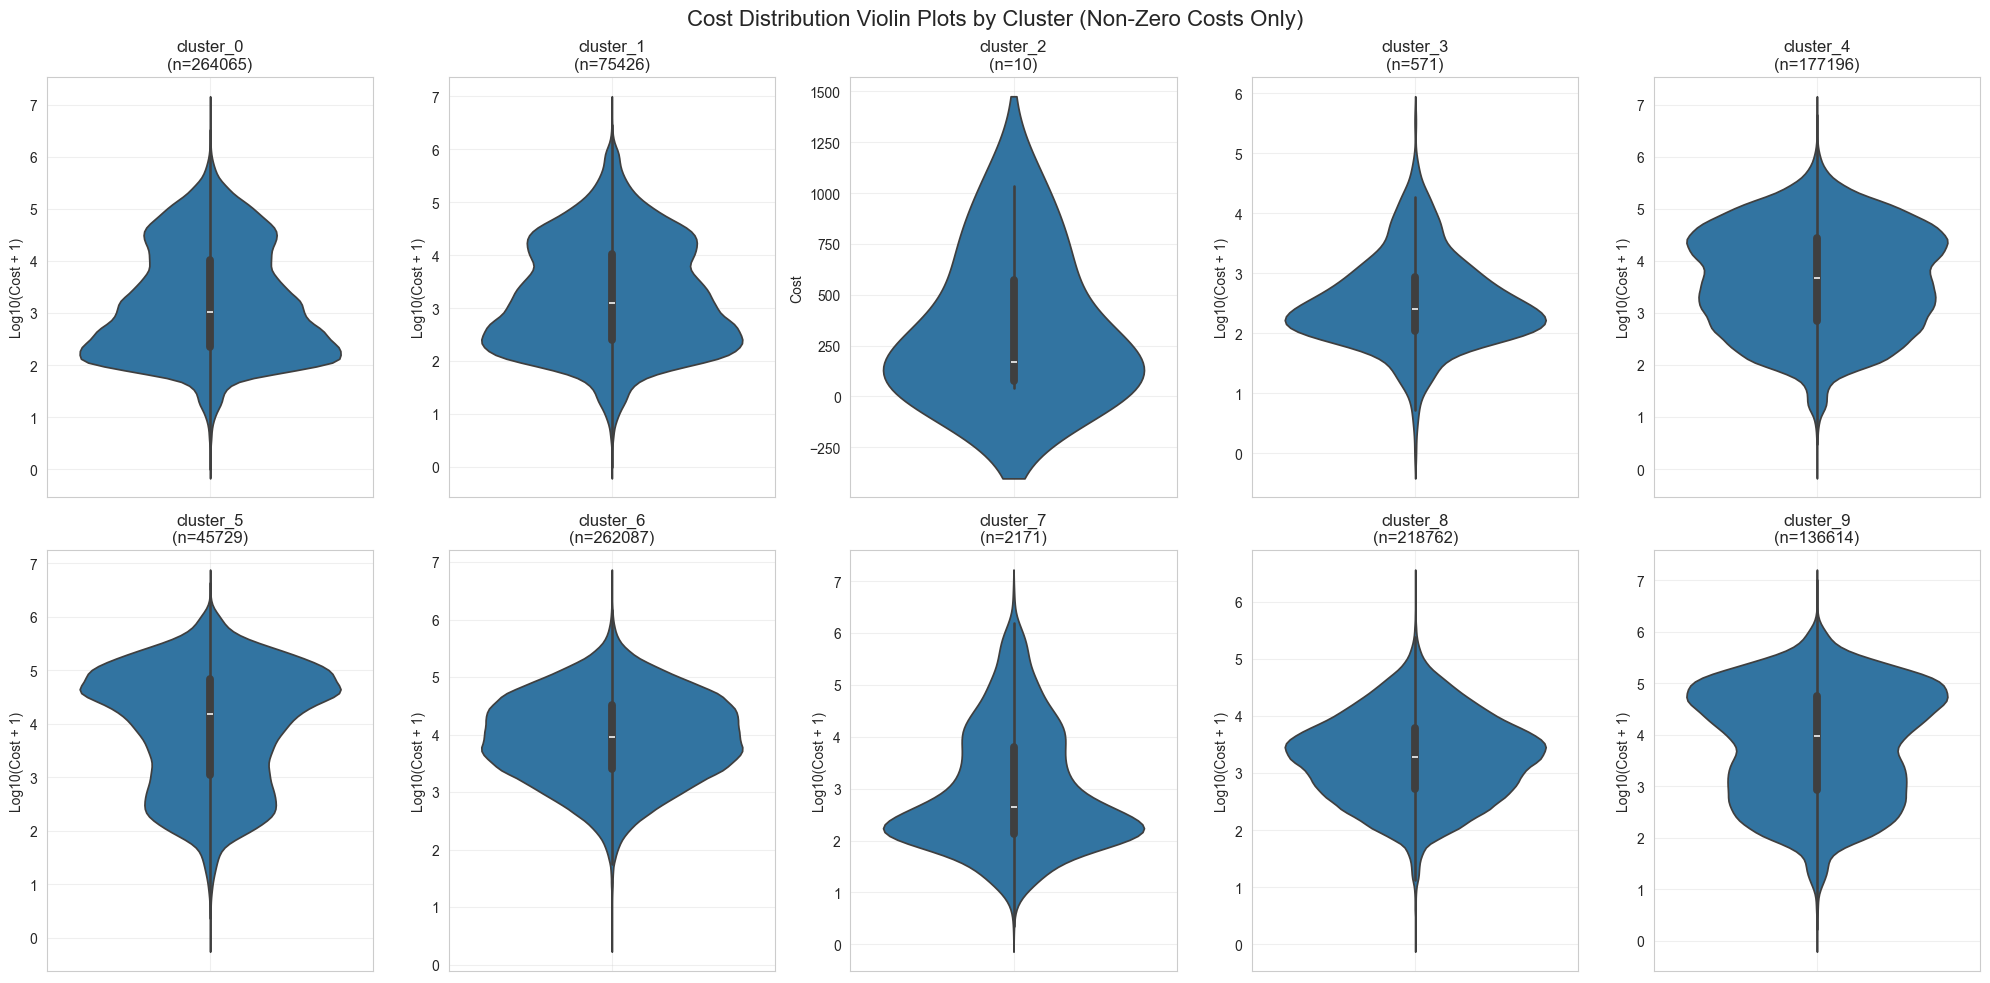

In [11]:
# Violin plots for better distribution visualization
try:
    import seaborn as sns
    sns.set_style("whitegrid")
    
    # Create a long-format dataframe for seaborn
    violin_data = []
    for col in cluster_cols:
        non_zero_data = df_2018[df_2018[col] > 0][col]
        if len(non_zero_data) > 0:
            for val in non_zero_data:
                violin_data.append({'Cluster': col, 'Cost': val})
    
    violin_df = pd.DataFrame(violin_data)
    
    if len(violin_df) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(20, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(cluster_cols):
            ax = axes[idx]
            cluster_data = violin_df[violin_df['Cluster'] == col]['Cost']
            
            if len(cluster_data) > 0:
                # Use log scale for better visualization if data spans wide range
                if cluster_data.max() / cluster_data.min() > 100:
                    sns.violinplot(y=np.log10(cluster_data + 1), ax=ax)
                    ax.set_ylabel('Log10(Cost + 1)')
                else:
                    sns.violinplot(y=cluster_data, ax=ax)
                    ax.set_ylabel('Cost')
                
                ax.set_title(f'{col}\n(n={len(cluster_data)})')
                ax.set_xlabel('')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                ax.set_title(col)
        
        plt.suptitle('Cost Distribution Violin Plots by Cluster (Non-Zero Costs Only)', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("No non-zero data available for violin plots")
except ImportError:
    # Fallback to matplotlib violin plots if seaborn is not available
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(cluster_cols):
        ax = axes[idx]
        non_zero_data = df_2018[df_2018[col] > 0][col].values
        
        if len(non_zero_data) > 0:
            # Use log scale for better visualization if data spans wide range
            if non_zero_data.max() / non_zero_data.min() > 100:
                plot_data = np.log10(non_zero_data + 1)
                ax.violinplot([plot_data], positions=[1], showmeans=True, showmedians=True)
                ax.set_ylabel('Log10(Cost + 1)')
            else:
                ax.violinplot([non_zero_data], positions=[1], showmeans=True, showmedians=True)
                ax.set_ylabel('Cost')
            
            ax.set_title(f'{col}\n(n={len(non_zero_data)})')
            ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(col)
    
    plt.suptitle('Cost Distribution Violin Plots by Cluster (Non-Zero Costs Only)', fontsize=16)
    plt.tight_layout()
    plt.show()


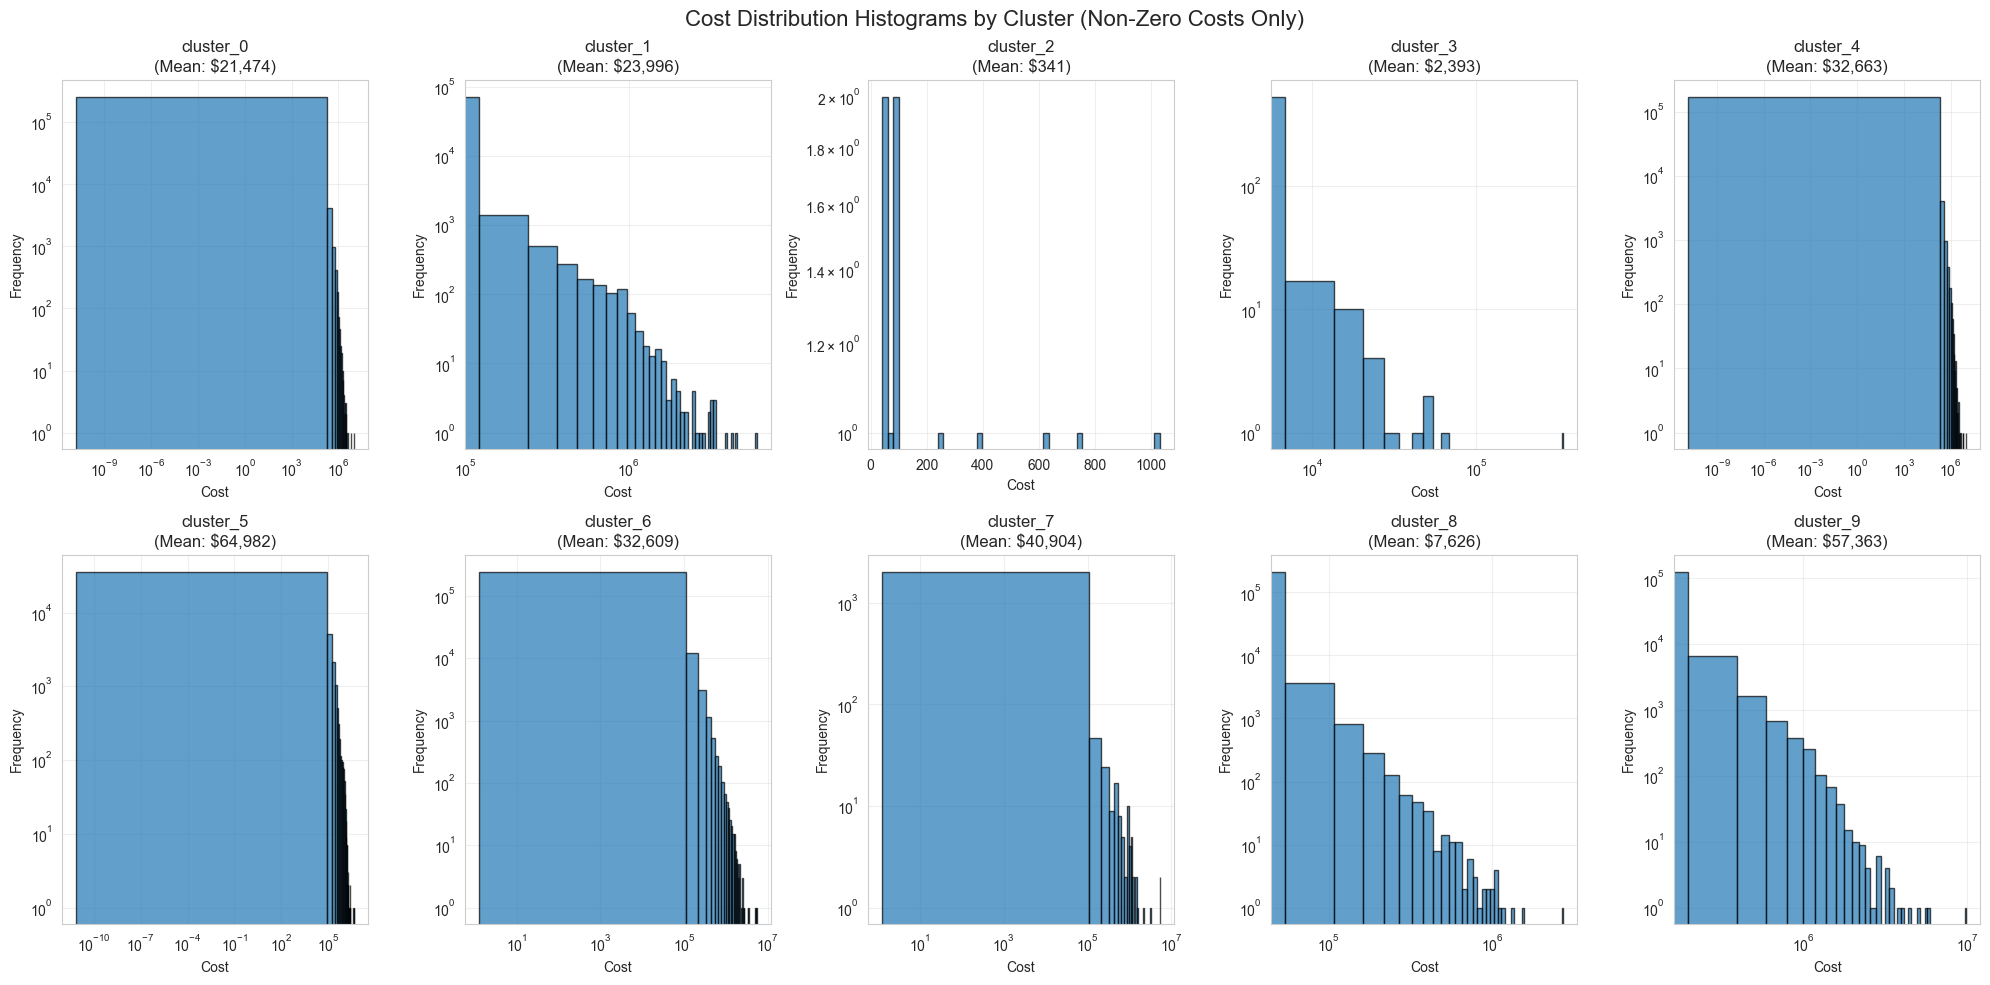

In [12]:
# Histograms for cost distributions (log scale)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(cluster_cols):
    ax = axes[idx]
    non_zero_data = df_2018[df_2018[col] > 0][col]
    
    if len(non_zero_data) > 0:
        ax.hist(non_zero_data, bins=50, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}\n(Mean: ${non_zero_data.mean():,.0f})')
        ax.set_xlabel('Cost')
        ax.set_ylabel('Frequency')
        ax.set_yscale('log')  # Log scale for y-axis if needed
        if non_zero_data.max() / non_zero_data.min() > 100:
            ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(col)

plt.suptitle('Cost Distribution Histograms by Cluster (Non-Zero Costs Only)', fontsize=16)
plt.tight_layout()
plt.show()


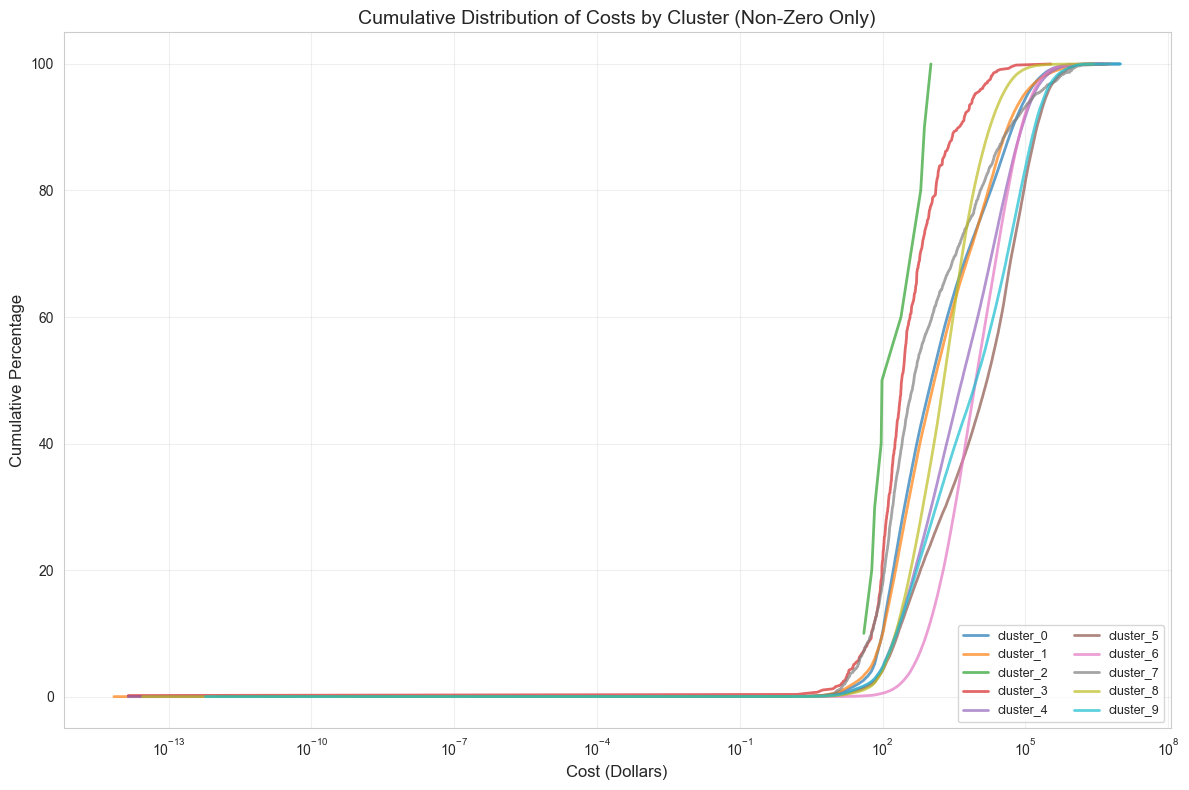

In [ ]:
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(12, 8))

for col in cluster_cols:
    non_zero_data = df_2018[df_2018[col] > 0][col]
    if len(non_zero_data) > 0:
        sorted_data = np.sort(non_zero_data)
        cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
        ax.plot(sorted_data, cumulative, label=col, linewidth=2, alpha=0.7)

ax.set_xlabel('Cost (Dollars)', fontsize=12)
ax.set_ylabel('Cumulative Percentage', fontsize=12)
ax.set_title('Cumulative Distribution of Costs by Cluster (Non-Zero Only)', fontsize=14)
ax.legend(loc='lower right', ncol=2, fontsize=9)
ax.set_xscale('log')  # Log scale for better visualization
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
